In [1]:
import torch
import time
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, replace
from typing import Sequence, Tuple

from dispertorch import ConstantEps, ConstantIndex
from metashapes.shape import Rectangle, Ellipse, RegularPolygon

from metarcwa import IsotropicMedium, Source, Stack, Lattice, Model, Layer
from metarcwa.model.adapters import from_dispertorch, from_metashapes
from metarcwa import Config, Solver, Factorization, Observables
from metarcwa.solver.harmonics import harmonic_index_map

In [2]:
def build_model(w: torch.Tensor,
                h: torch.Tensor,
                angle: torch.Tensor,
                thickness: torch.Tensor,
                eps_solid: ConstantEps,
                eps_void: ConstantEps,
                eps_inc: ConstantEps,
                eps_trans: ConstantEps,
                period: torch.Tensor,
                wl: torch.Tensor,
                theta: torch.Tensor) -> Model:
    """Build a single-patterned-layer Model between two half-spaces.

    The layer's in-plane permittivity is ``shape`` (filled with ``eps_solid``)
    embedded in a background of ``eps_void``, on a square lattice of period
    ``period``. The layer sits between an incidence half-space (``eps_inc``)
    and a transmission half-space (``eps_trans``).

    Parameters
    ----------
    w: torch.Tensor
        Bar width.
    thickness : torch.Tensor
        Layer thickness.
    eps_solid, eps_void : ConstantEps
        Dispersion models for the shape's fill / background, wrapped into
        ``IsotropicMedium`` via ``from_dispertorch``.
    eps_inc, eps_trans : ConstantEps
        Dispersion models for the incidence / transmission half-spaces.
    period : torch.Tensor
        Square lattice period (px = py).
    wl : torch.Tensor
        Free-space wavelength(s).
    theta : torch.Tensor
        Polar incidence angle(s) in radians, measured from the interface
        normal.

    Returns
    -------
    Model
        Ready to pass to ``Solver``.
    """
    medium_inc = IsotropicMedium(from_dispertorch(eps_inc))
    medium_trans = IsotropicMedium(from_dispertorch(eps_trans))
    medium_solid = IsotropicMedium(from_dispertorch(eps_solid))
    medium_void = IsotropicMedium(from_dispertorch(eps_void))

    lattice = Lattice.rectangular(px=period, py=period)
    layer = Layer(medium_solid, thickness, medium_void, 
                  from_metashapes(Ellipse((period/2, period/2), (w, h), angle)))
    stack = Stack(medium_inc, [layer], medium_trans, lattice)
    src = Source(wl, theta, phi=0.0)

    return Model(stack, src)


def build_config(dtype: torch.dtype, device: torch.device,
                 m: int, n: int, nx: int, ny: int,
                 factorization: Factorization | None,
                 truncation: str = "circular",
                 modesolver: str = "eig") -> Config:
    """Build a Config from a Factorization instance directly (or None to
    disable TVF). Kept separate from `Factorization(...)` construction so
    callers can build variant configs via `dataclasses.replace(base_config, ...)`.
    """
    return Config(dtype, device, m=m, n=n, nx=nx, ny=ny,
                  truncation=truncation, factorization=factorization, modesolver=modesolver)
    
def compute_rt(model: Model, config: Config) -> Tuple[torch.Tensor, torch.Tensor,
                                                        torch.Tensor, torch.Tensor]:
    """Solve the stack and return specular-order power R/T for both polarizations.

    Same convention as ``interface.ipynb``'s ``compute_rt``: reflectance is
    ``|r|**2``; transmittance additionally carries the Poynting-flux ratio
    ``Re(n_sub*cos(theta_t)) / Re(n_inc*cos(theta_i))`` between the incidence
    and transmission half-spaces (unaffected by whatever finite layer sits in
    between -- it depends only on the two half-spaces and the angle).

    Returns
    -------
    Rs, Rp, Ts, Tp : torch.Tensor
        Shape ``[N_wl, N_theta, N_phi]``, matching ``Source``'s sweep axes.
    """
    solver = Solver(model, config)
    solution = solver.run()
    obs = Observables(solution)

    rs, _ = obs.reflection(pol='s')
    _, rp = obs.reflection(pol='p')
    Rs = torch.abs(rs.cpu())**2
    Rp = torch.abs(rp.cpu())**2

    ts, _ = obs.transmission(pol='s')
    _, tp = obs.transmission(pol='p')

    n1 = (model.stack.incidence.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)
    n2 = (model.stack.transmission.eps_fn(model.source.wavelength)**0.5).cpu().reshape(-1, 1, 1)

    theta = model.source.theta.cpu().reshape(1, -1, 1)
    cos_i = torch.cos(theta)
    sin_t = (n1 / n2) * torch.sin(theta)
    cos_t = torch.sqrt(1 - sin_t**2 + 0j)
    coeff = torch.real(n2 * cos_t) / torch.real(n1 * cos_i)

    Ts = coeff * torch.abs(ts.cpu())**2
    Tp = coeff * torch.abs(tp.cpu())**2
    return Rs, Rp, Ts, Tp

Eigensolver time: 5.1447837352752686 s
Matrix Exponential time: 2.0436806678771973 s


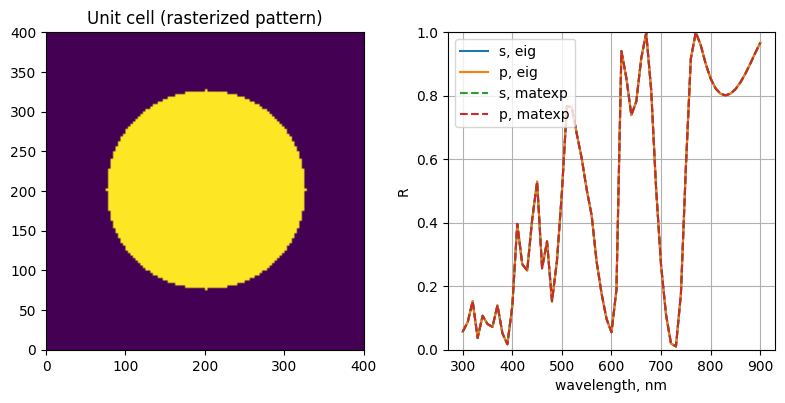

In [4]:
# Define config
dtype = torch.float32
device = "cuda:1"
m = 10
n = 10
nx = 128
ny = 128
truncation = "circular"
factorization = Factorization(method="Jones")


# Define model parameters
eps_inc  = ConstantEps(1)
eps_solid  = ConstantIndex(3.8, k=0.0)    
eps_subs = ConstantIndex(1.46)

w = torch.tensor(250.0)
h = torch.tensor(250.0)
angle = 0.0
thickness = torch.tensor(200.0)   # nm
period    = 400

wl    = torch.linspace(300.0, 900.0, 61)
theta = torch.tensor([0.0])       # ~17 deg, fixed

model = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc, eps_subs, period, wl, theta)

# Eigensolver
modesolver = "eig"
config_eig = build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver=modesolver)
start = time.time()
Rs_eig, Rp_eig, Ts_eig, Tp_eig = compute_rt(model, config_eig)
end = time.time()
print(f"Eigensolver time: {end - start} s")

# Matrix exponential solver
modesolver = "matexp"
config_matexp = build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver=modesolver)
start = time.time()
Rs_matexp, Rp_matexp, Ts_matexp, Tp_matexp = compute_rt(model, config_matexp)
end = time.time()
print(f"Matrix Exponential time: {end - start} s")

plt.figure(figsize=(8, 4))
plt.subplot(121)
plt.imshow(model.spec(nx=nx, ny=ny).layers[0].pattern.cpu(), origin="lower", extent=(0, period, 0, period))
plt.title("Unit cell (rasterized pattern)")

plt.subplot(122)
plt.plot(wl, Rs_eig[:,0,0], label='s, eig')
plt.plot(wl, Rp_eig[:,0,0], label='p, eig')
plt.plot(wl, Rs_matexp[:,0,0], '--', label='s, matexp')
plt.plot(wl, Rp_matexp[:,0,0], '--', label='p, matexp')
plt.grid()
plt.ylabel('R')
plt.xlabel('wavelength, nm')
plt.legend()
plt.ylim([0, 1.0])

plt.tight_layout()

## Why does `float64` erase matexp's speed edge, and why does `float32` diverge at some wavelengths?

Two things worth understanding about `modesolver="matexp"` vs `"eig"`, beyond the plot above:

1. **`float64` timing parity.** `matexp` swaps an eigendecomposition (`torch.linalg.eig` — latency/reduction-bound, only ~4x slower in `complex128`) for a dense `matrix_exp` (GEMM-bound — measured ~35-40x slower in `complex128` on a consumer GPU's crippled fp64 datapath). So matexp's fp32 speed advantage largely disappears at fp64 on cards like this one — a GPU/dtype effect, not an algorithm defect. See `docs/matrixexp.md` "Cost model".
2. **`float32` wavelength-localized divergence.** Every slice's S-matrix is referenced to a *fictitious* vacuum-embedded sub-slab of the patterned layer — an artifact of slicing, not a physical object — and that fictitious slab has its own sharp, wavelength-dependent resonances. `star_power`'s repeated-squaring recombination visits thicknesses `(d/n)*2^k`; for even `n`, several of those are exact dyadic fractions of `d`, and if one lands on a fictitious-slab resonance the Redheffer star product's internal solve becomes severely ill-conditioned (`cond ~ 2e5`), costing a few percent relative error at `complex64` (negligible at `complex128`). The solver now nudges its automatic slice count off that dyadic ladder and warns if a resonance still looks like it was hit — see `docs/matrixexp.md` "Accuracy and conditioning" for the full derivation and measurements.

The cells below reproduce both findings on this notebook's own structure.

In [5]:
import warnings

def time_split(model_, config):
    """Time Solver.__init__ (prepare) and .run() (assemble/cascade) separately."""
    dev = torch.device(config.device)
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
    t0 = time.time()
    solver = Solver(model_, config)
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
    t1 = time.time()
    solution = solver.run()
    if dev.type == "cuda":
        torch.cuda.synchronize(dev)
    t2 = time.time()
    return solver, solution, t1 - t0, t2 - t1

# A reduced wavelength subset keeps this memory-safe on modest GPUs -- matexp
# densifies a 4Nh x 4Nh system matrix per slice, ~4x the eig path's 2Nh x 2Nh.
wl_timing = wl[:20]
model_timing = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc,
                            eps_subs, period, wl_timing, theta)

print(f"{'dtype':10s} {'modesolver':10s} {'init (s)':>10s} {'run (s)':>10s} {'total (s)':>10s}")
for dt in (torch.float32, torch.float64):
    for ms in ("eig", "matexp"):
        cfg = build_config(dt, device, m, n, nx, ny, factorization, truncation, modesolver=ms)
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            solver, solution, t_init, t_run = time_split(model_timing, cfg)
        print(f"{str(dt).split('.')[-1]:10s} {ms:10s} {t_init:10.2f} {t_run:10.2f} {t_init + t_run:10.2f}")
        del solver, solution
        if torch.device(device).type == "cuda":
            torch.cuda.empty_cache()

dtype      modesolver   init (s)    run (s)  total (s)
float32    eig              2.01       0.24       2.24
float32    matexp           0.75       0.55       1.30
float64    eig              6.49       2.13       8.62
float64    matexp           0.80       6.77       7.57


eig, float32                     max|dR|=2.96e-04  rms=9.15e-05  at wl=860.0 nm
matexp, float32 (auto slices)    max|dR|=1.52e-03  rms=2.41e-04  at wl=600.0 nm

star_power resonance-guard warnings fired: 1


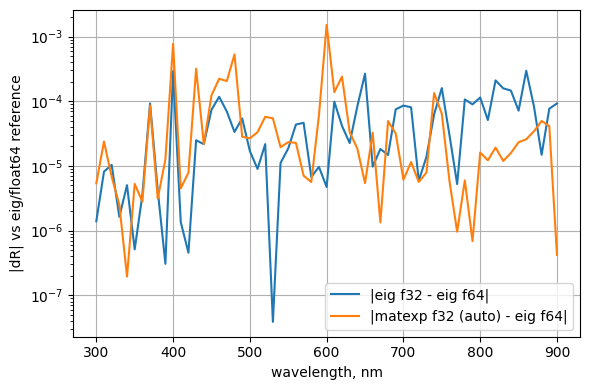

In [6]:
# --- fp32 accuracy vs an eig/float64 reference, across the full sweep ---
# Chunked over wavelength to bound peak memory regardless of GPU size.
def compute_rt_chunked(config, chunk=10):
    Rs_l, Rp_l, Ts_l, Tp_l = [], [], [], []
    for i in range(0, wl.shape[0], chunk):
        wl_chunk = wl[i:i + chunk]
        m_chunk = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc,
                               eps_subs, period, wl_chunk, theta)
        Rs_c, Rp_c, Ts_c, Tp_c = compute_rt(m_chunk, config)
        Rs_l.append(Rs_c); Rp_l.append(Rp_c); Ts_l.append(Ts_c); Tp_l.append(Tp_c)
        del m_chunk
        if torch.device(config.device).type == "cuda":
            torch.cuda.empty_cache()
    return torch.cat(Rs_l), torch.cat(Rp_l), torch.cat(Ts_l), torch.cat(Tp_l)

config_ref = build_config(torch.float64, device, m, n, nx, ny, factorization, truncation, modesolver="eig")
Rs_ref, *_ = compute_rt_chunked(config_ref)

config_eig32 = build_config(torch.float32, device, m, n, nx, ny, factorization, truncation, modesolver="eig")
Rs_eig32, *_ = compute_rt_chunked(config_eig32)

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    config_matexp32 = build_config(torch.float32, device, m, n, nx, ny, factorization, truncation, modesolver="matexp")
    Rs_matexp32, *_ = compute_rt_chunked(config_matexp32)
    n_resonance_warnings = sum(1 for w_ in caught if "resonance guard" in str(w_.message))

for name, Rs in [("eig, float32", Rs_eig32), ("matexp, float32 (auto slices)", Rs_matexp32)]:
    d = (Rs[:, 0, 0] - Rs_ref[:, 0, 0]).abs()
    i = int(d.argmax())
    print(f"{name:32s} max|dR|={float(d.max()):.2e}  rms={float((d ** 2).mean() ** 0.5):.2e}  "
          f"at wl={float(wl[i]):.1f} nm")
print(f"\nstar_power resonance-guard warnings fired: {n_resonance_warnings}")

plt.figure(figsize=(6, 4))
plt.plot(wl, (Rs_eig32[:, 0, 0] - Rs_ref[:, 0, 0]).abs(), label='|eig f32 - eig f64|')
plt.plot(wl, (Rs_matexp32[:, 0, 0] - Rs_ref[:, 0, 0]).abs(), label='|matexp f32 (auto) - eig f64|')
plt.yscale('log')
plt.grid()
plt.xlabel('wavelength, nm')
plt.ylabel('|dR| vs eig/float64 reference')
plt.legend()
plt.tight_layout()

Scanning at the worst wavelength found above: 600.0 nm


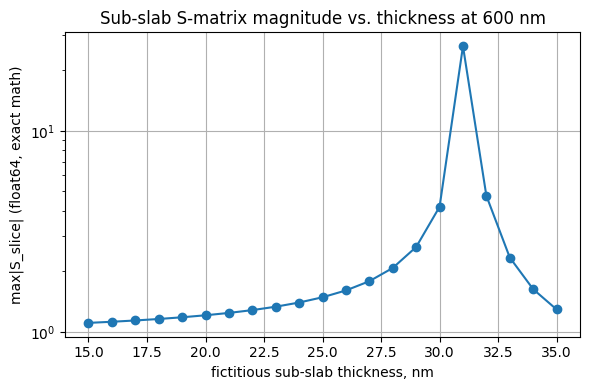

In [7]:
# --- The mechanism: a fictitious vacuum-embedded sub-slab's own resonance ---
# Reaches into solver internals (Solver._ops, LayerSolver.background) purely to
# illustrate what star_power's slices are actually built from -- not needed for
# ordinary use of the solver.
from metarcwa.solver.layersolver.matexpsolver import system_matrix, transfer_matrix, transfer_to_smatrix

worst_idx = int((Rs_matexp32[:, 0, 0] - Rs_ref[:, 0, 0]).abs().argmax())
worst_wl = wl[worst_idx].reshape(1)
print(f"Scanning at the worst wavelength found above: {float(worst_wl):.1f} nm")

model_1wl = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc,
                         eps_subs, period, worst_wl, theta)
cfg_probe = build_config(torch.float64, device, m, n, nx, ny, factorization, truncation, modesolver="matexp")
solver_probe = Solver(model_1wl, cfg_probe)
op = solver_probe._ops[1]                      # the single patterned layer's TransferOperator
background = solver_probe.layersolver.background
k0 = 2 * torch.pi / torch.as_tensor(background.wvl)
A = system_matrix(op.P, op.Q)

# max|S| of a *fictitious* vacuum-embedded slab of the layer's material, as a
# function of its own thickness -- computed in float64 so this is exact math,
# not roundoff. star_power's squaring ladder visits exactly these thicknesses
# (as fractions of the real layer thickness) when combining slices.
sub_thicknesses = torch.linspace(15.0, 35.0, 21, dtype=torch.float64)
mags = []
for t in sub_thicknesses:
    T = transfer_matrix(A, op.Nh, k0, t)
    S = transfer_to_smatrix(T, background)
    mags.append(float(S.to_dense().abs().max()))

plt.figure(figsize=(6, 4))
plt.plot(sub_thicknesses, mags, marker='o')
plt.yscale('log')
plt.xlabel('fictitious sub-slab thickness, nm')
plt.ylabel('max|S_slice| (float64, exact math)')
plt.title(f'Sub-slab S-matrix magnitude vs. thickness at {float(worst_wl):.0f} nm')
plt.grid()
plt.tight_layout()

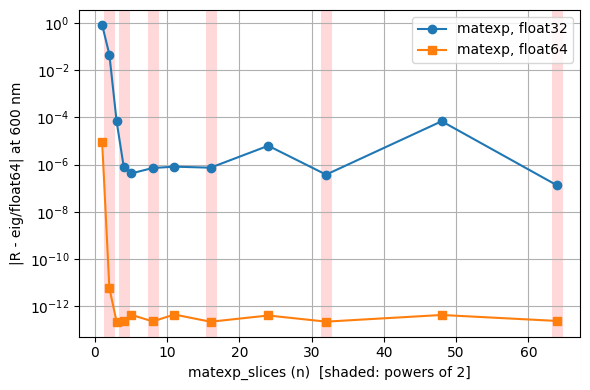

In [8]:
# --- Error vs. explicit slice count at the worst wavelength: odd beats even ---
def reflectance_s(wl_single, dtype, slices):
    cfg = replace(
        build_config(dtype, device, m, n, nx, ny, factorization, truncation, modesolver="matexp"),
        matexp_slices=slices,
    )
    model_ = build_model(w, h, angle, thickness, eps_solid, eps_inc, eps_inc,
                          eps_subs, period, wl_single, theta)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        Rs, *_ = compute_rt(model_, cfg)
    return float(Rs[0, 0, 0])

ref_val = float(Rs_ref[worst_idx, 0, 0])

ns = [1, 2, 3, 4, 5, 8, 11, 16, 24, 32, 48, 64]
errs32 = [abs(reflectance_s(worst_wl, torch.float32, n_) - ref_val) for n_ in ns]
errs64 = [abs(reflectance_s(worst_wl, torch.float64, n_) - ref_val) for n_ in ns]

plt.figure(figsize=(6, 4))
plt.semilogy(ns, errs32, 'o-', label='matexp, float32')
plt.semilogy(ns, errs64, 's-', label='matexp, float64')
for n_ in ns:
    if n_ > 1 and (n_ & (n_ - 1)) == 0:      # powers of two -- on the dyadic ladder
        plt.axvline(n_, color='r', alpha=0.15, lw=8, zorder=0)
plt.xlabel('matexp_slices (n)  [shaded: powers of 2]')
plt.ylabel(f'|R - eig/float64| at {float(worst_wl):.0f} nm')
plt.legend()
plt.grid()
plt.tight_layout()